In [1]:
#Import relevant packages
import worldtube_postprocess as wpp
import matplotlib.pyplot as plt
import numpy as np
from spectre.SphericalHarmonics import SpherepackIterator
import h5py
import sys

# if len(sys.argv) < 2:
#     raise ValueError("Please provide a file name as an argument.")

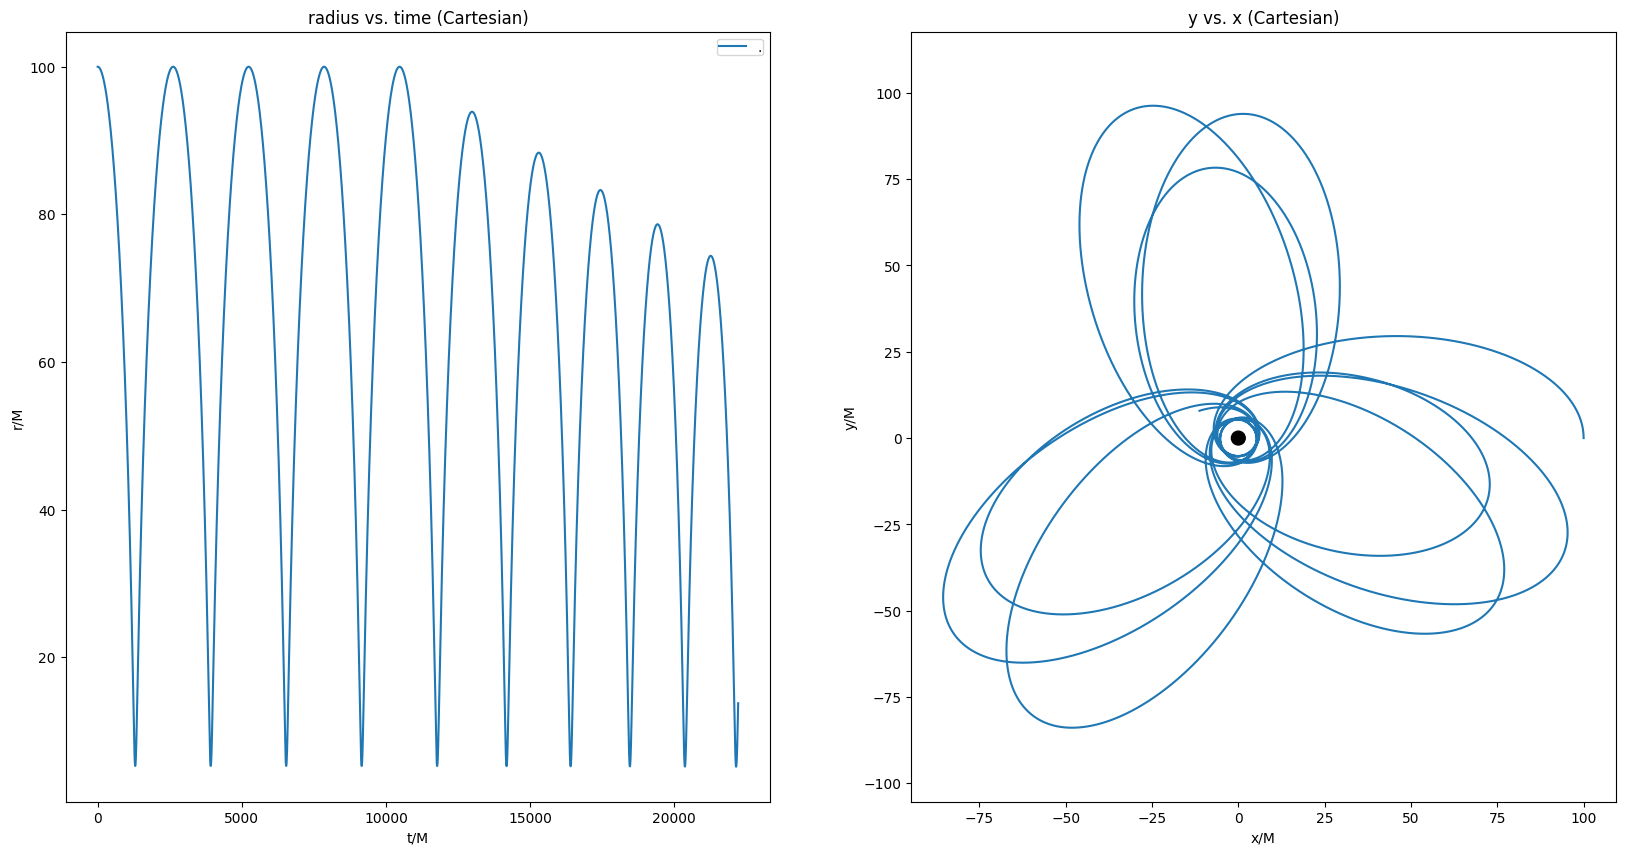

In [2]:
#Extract out the simulation data for trajectory plot
file_list=['.']
sim_data={n:wpp.extract_sim_data(n) for n in file_list}
traj_pos=[sim_data[n]['position'] for n in file_list]
time=[sim_data[n]['times'] for n in file_list]

#Plot the trajectory
fig,ax=plt.subplots(1,2,figsize=(20,10))
# ax[1]=plt.subplot(122,projection='polar')
labellist=[['t/M','r/M','radius vs. time (Cartesian)'],['x/M','y/M','y vs. x (Cartesian)']]
for n,row in enumerate(ax):
    row.set_xlabel(labellist[n][0])
    row.set_ylabel(labellist[n][1])
    row.set_title(labellist[n][2])
for i,n in enumerate(file_list):
    ax[1].plot(traj_pos[i][:,0],traj_pos[i][:,1],'-',label=n,markersize=1)
    ax[0].plot(time[i],np.sqrt(traj_pos[i][:,0]**2+traj_pos[i][:,1]**2),label=n)
    # ax[0].set_ylim([8-1e-4,8+1e-4])  # Adjust the y-limits to zoom in on the radius
    # ax[0].set_xlim([0,1000])
plt.axis('equal')
event_horizon=plt.Circle((0,0),radius=2,color='k')
ax[1].add_patch(event_horizon)
ax[0].legend(loc='upper right',borderpad=0.1)
plt.savefig('trajectory_plot.png',bbox_inches='tight')
plt.show()

Fraction of data points with < 3 real roots: 1.0
.


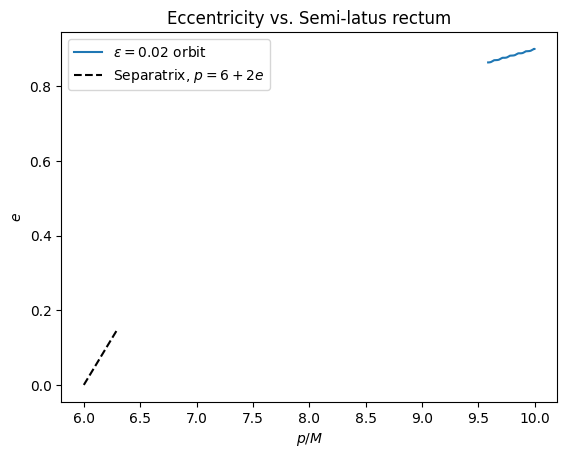

In [7]:
#Generate the p,e plot for inspirals
osc_data={n:wpp.get_osculating_elements(sim_data[n]) for n in file_list}
for key in osc_data:
    print(key)
    plt.plot(osc_data[key][2],osc_data[key][3],label=rf"$\epsilon={sim_data[key]['charge']}$ orbit")

p_sep=np.linspace(6,6.3,100)
e_sep=(p_sep-6)/2
plt.plot(p_sep,e_sep,'k--',label=r'Separatrix, $p=6+2e$')

plt.ylabel(r'$e$')
plt.xlabel(r'$p/M$')
plt.title(r'Eccentricity vs. Semi-latus rectum')
plt.savefig('semi-ecc_plot.pdf',bbox_inches='tight')
plt.legend()
plt.show()

In [4]:
final_index=2

#Extract out the simulation data for spherical harmonic modes
full_sphere_data = {n:wpp.extract_sphere_data(n) for n in file_list[:]}
time_sph = {n:full_sphere_data[n][0] for n in file_list[:]}
sphere_pack = {n:full_sphere_data[n][1] for n in file_list[:]}
radii = {n:full_sphere_data[n][2] for n in file_list[:]}

#Extract out the l_max value for the simulation 
# Get lmax from datafile
with h5py.File(f"{file_list[0]}/Reductions.h5", "r") as h5file:
    dat_file = h5file.get("/Spheres_Ylm.dat")
    legend = list(dat_file.attrs["Legend"])
    lmax = int(dat_file[0, legend.index("Lmax")])
    print("lmax : ", lmax)

# print(radii)
# print(sphere_pack.shape,time_sph.shape)

lmax :  10


The (l,m) modes are: [(0, 0), (1, 0), (1, 1), (2, 0), (2, 1), (2, 2)]


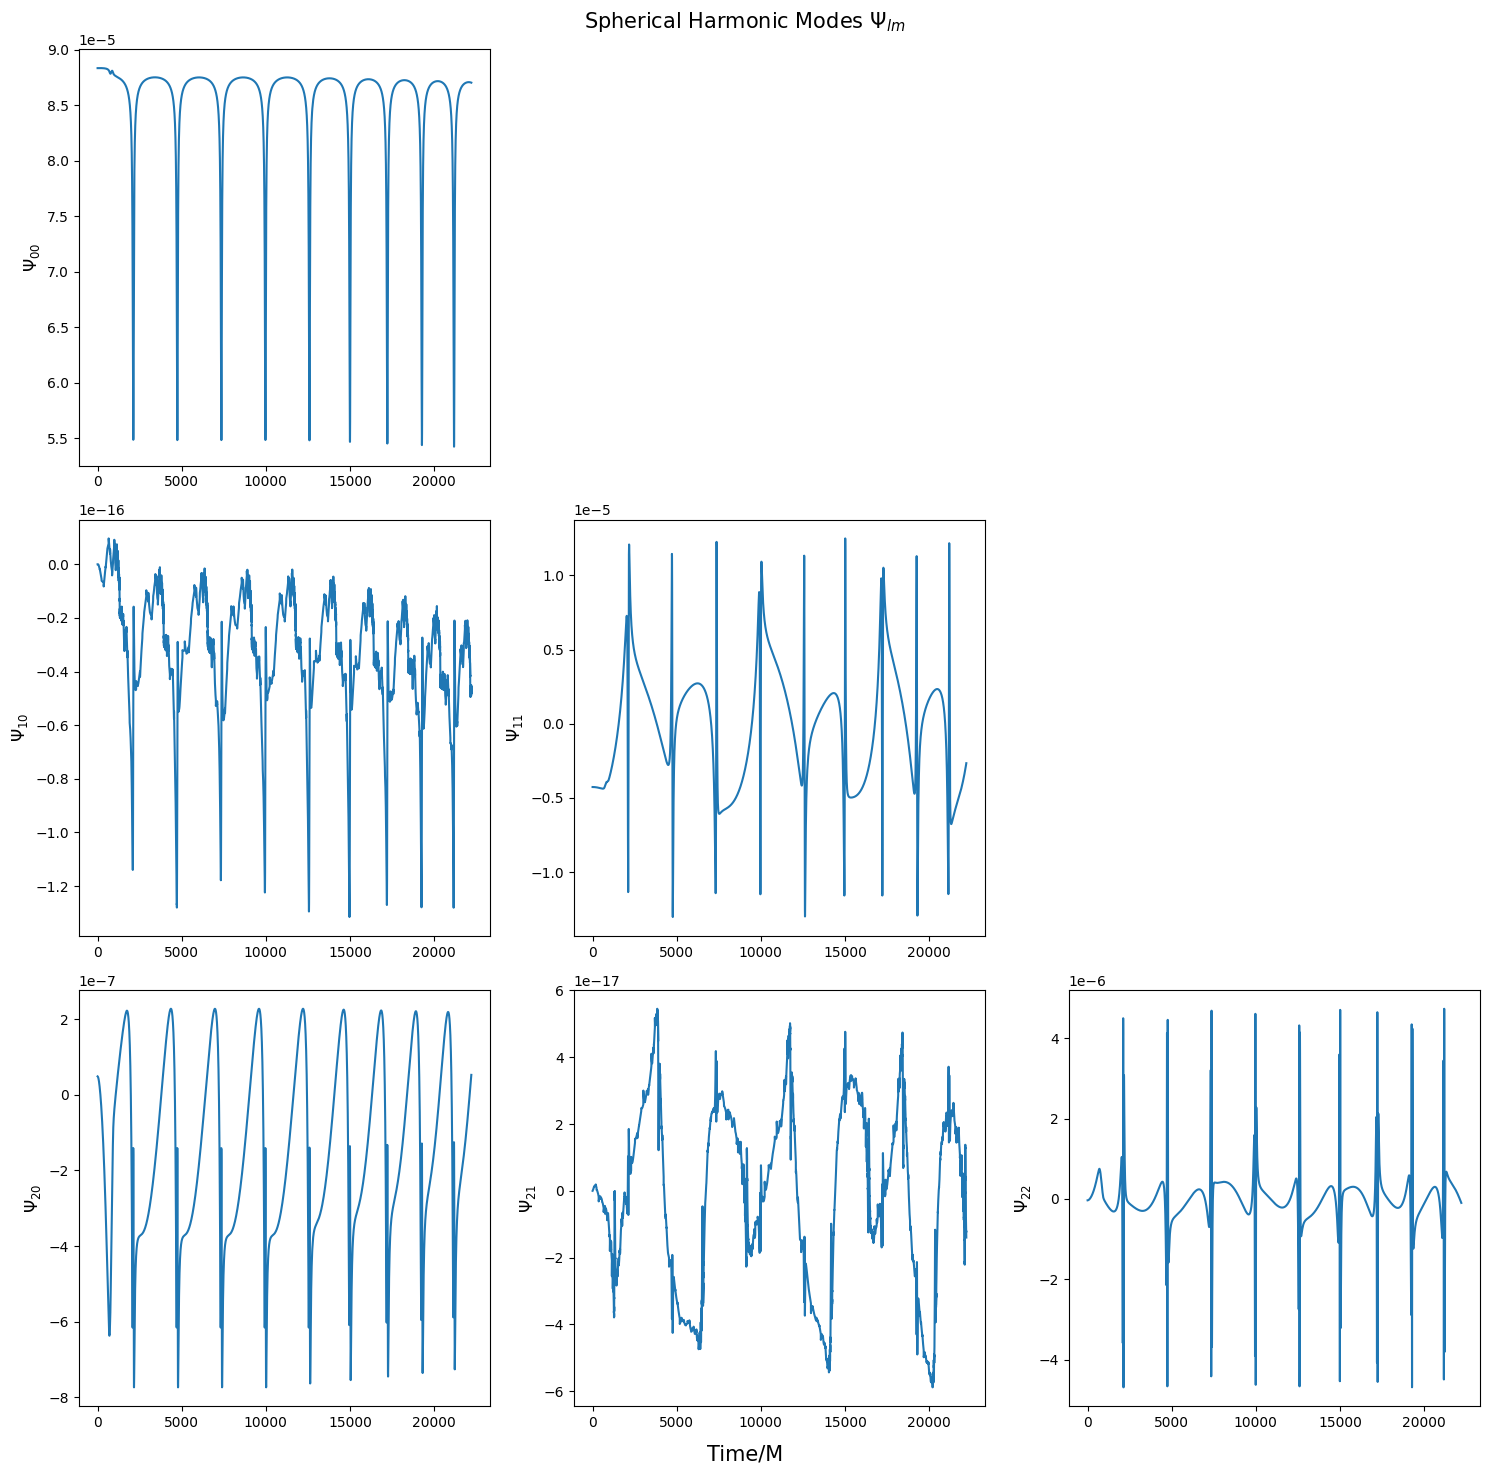

In [5]:
#Plot the spherical harmonic modes
#Generate the modes to plot
lmodes = range(3)
lm_modes = [(l_temp, m) for l_temp in lmodes for m in range(0,l_temp+1)]
print('The (l,m) modes are:',lm_modes)

#Extract out the Psi_lm modes from the data
Psi_dict={n:{(l,m):[time_sph[n],wpp.ylm(data=sphere_pack[n][0],l=l,m=m,l_max=lmax)] for (l,m) in lm_modes} for n in file_list[:]}

#Plot the modes
fig,ax=plt.subplots(lm_modes[-1][0]+1,lm_modes[-1][1]+1,figsize=(15,15))
for l in range(lm_modes[-1][0]+1):
    for m in range(lm_modes[-1][1]+1):
        if l<m:
            ax[l][m].axis('off')  # Hide the subplot if l < m
        else:
            ax[l][m].plot(Psi_dict[file_list[0]][(l,m)][0],Psi_dict[file_list[0]][(l,m)][1],label=f'l={l}, m={m}')
            ax[l][m].set_ylabel(rf'$\Psi_{{{l}{m}}}$',fontsize=12)
fig.suptitle(r'Spherical Harmonic Modes $\Psi_{lm}$', fontsize=15)
fig.supxlabel('Time/M', fontsize=15)
plt.tight_layout()
plt.savefig('spherical_harmonic_modes.png',bbox_inches='tight')
plt.show()


WT_Radius: [[2.00000000e-01 0.00000000e+00]
 [4.00000000e-01 2.27007391e-05]
 [8.00000000e-01 5.24658602e-05]
 [1.60000000e+00 9.04804278e-05]
 [2.00000000e+00 1.11896699e-04]]
\alpha, A: [9.04662885e-01 5.97717019e-05]


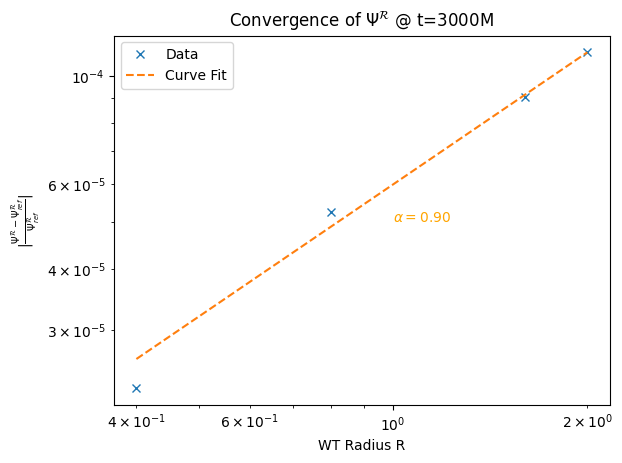

<Figure size 640x480 with 0 Axes>

In [12]:
#Extracting Psi_00 for t_choice
Psi_00_stable={}
t_choice=3000
for n in file_list[:]:
    t_stable=np.argmin(abs(Psi_dict[n][(0,0)][0]-t_choice))
    Comparison_val=[Psi_dict[n][(0,0)][0][t_stable],Psi_dict[n][(0,0)][1][t_stable]]
    Psi_00_stable[n]=Comparison_val
# print(Psi_00_400)

#Create our Error of Psi^R with Psi^R_ref
WT_Radius=np.zeros((len(file_list[:]),2))
WT_Radius[:,0]=[0.2,0.4,0.8,1.6,2.0]
for i,n in enumerate(file_list[:]):
    WT_Radius[i,1]=abs(Psi_00_stable[n][1]/Psi_00_stable[file_list[0]][1]-1)
print('WT_Radius:',WT_Radius)

#Fitting for the values
from scipy.optimize import curve_fit
def fit_func(wt, a, b):
    return b * (wt ** a)
popt,pcov=curve_fit(fit_func,WT_Radius[1:,0],WT_Radius[1:,1],p0=[1.2,1e-4])
print(r"\alpha, A:",popt)
fit=popt[1]*(WT_Radius[1:,0]**popt[0])

#Plot the convergence of Psi^R
plt.plot(WT_Radius[1:,0],WT_Radius[1:,1],'x',label='Data')
# plt.plot(WT_Radius[1:,0],WT_Radius[1,1]*(WT_Radius[1:,0]/WT_Radius[1,0])**1.2,'--',label='Manual Fit')
plt.plot(WT_Radius[1:,0],fit,'--',label='Curve Fit')

plt.text(1,5e-5,rf'$\alpha={popt[0]:.2f}$',fontsize=10,color='orange')
plt.xlabel('WT Radius R')
plt.ylabel(r'$|\frac{\Psi^\mathcal{R}-\Psi^\mathcal{R}_{ref}}{\Psi^\mathcal{R}_{ref}}|$')
plt.yscale('log')
plt.xscale('log')
plt.title(rf'Convergence of $\Psi^\mathcal{{R}}$ @ t={t_choice}M')
plt.legend()
plt.show()
plt.savefig('convergence_plot.png',bbox_inches='tight')

In [ ]:
#Save the data for later use when combining plots.
file_name = sys.argv[1]  # Use the provided file name
file_name += '.txt'
file_path = '/urania/ptmp/cditt/worldtube-kerr/8M_circular/'
with open(file_path+file_name,'w') as f:
    np.savetxt(f,[popt])
    f.write('\n')
    np.savetxt(f,WT_Radius)